# Loan Approval Prediction

**Goal:** Predict loan approval (`Loan_Status`) from borrower features.

**Pipeline:** EDA → preprocessing → imbalance handling → model comparison → business interpretation.

Dataset: [Kaggle – Loan Approval Prediction Case Study](https://www.kaggle.com/datasets/bhanupratapbiswas/loan-approval-prediction-case-study)

In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
DATA_PATH = Path("data/loan_prediction.csv")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load data

In [4]:
df = pd.read_csv(DATA_PATH)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Exploratory Data Analysis

In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nSummary statistics:\n", df.describe(include="all").T)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False))
print("\nTarget distribution:\n", df["Loan_Status"].value_counts())
df["Loan_Status"].value_counts(normalize=True).mul(100).round(1)

Shape: (614, 13)

Data types:
 Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Summary statistics:
                    count unique        top freq         mean          std  \
Loan_ID              614    614   LP001002    1          NaN          NaN   
Gender               601      2       Male  489          NaN          NaN   
Married              611      2        Yes  398          NaN          NaN   
Dependents           599      4          0  345          NaN          NaN   
Education            614      2   Graduate  480          NaN          NaN   
Self_Employed        582      2         No  500          NaN          NaN   
ApplicantIncome  

Loan_Status
Y    68.7
N    31.3
Name: proportion, dtype: float64

### 2.1 Visualizations (key dataset aspects)

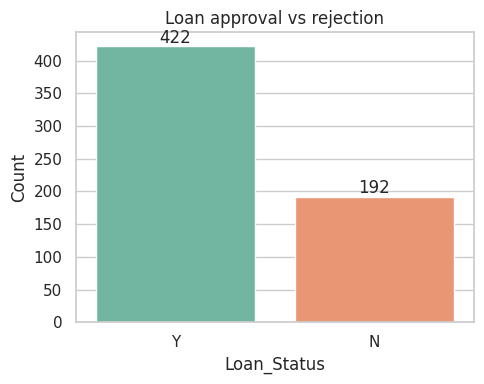

In [6]:
# 1) Target class balance
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Loan_Status"].value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, ax=ax, palette="Set2")
ax.set_title("Loan approval vs rejection")
ax.set_xlabel("Loan_Status")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_balance.png", dpi=120)
plt.show()

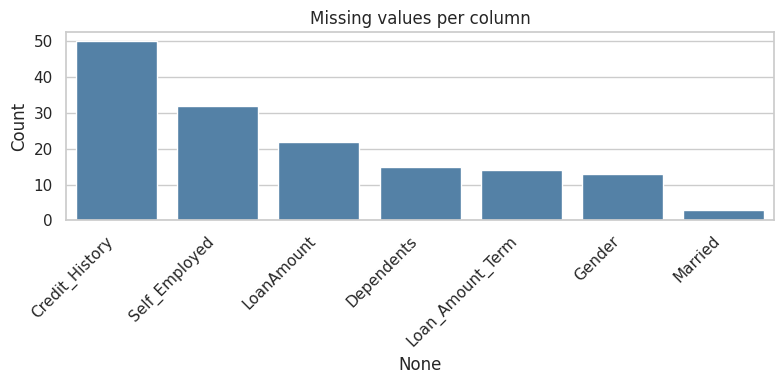

In [7]:
# 2) Missing values heatmap-style bar chart
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.index, y=missing.values, ax=ax, color="steelblue")
ax.set_title("Missing values per column")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_missing_values.png", dpi=120)
plt.show()

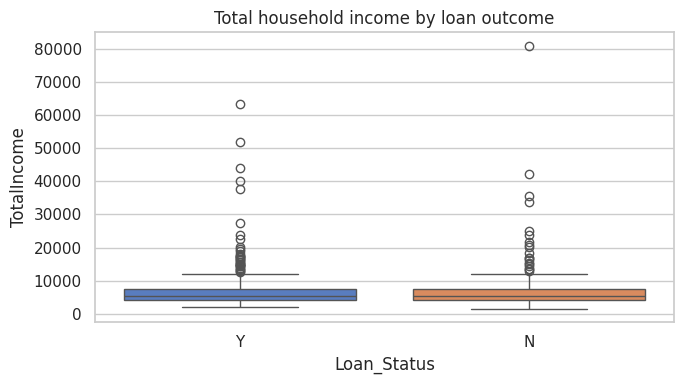

In [8]:
# 3) Income distributions by loan status
plot_df = df.copy()
plot_df["TotalIncome"] = plot_df["ApplicantIncome"] + plot_df["CoapplicantIncome"].fillna(0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=plot_df, x="Loan_Status", y="TotalIncome", hue="Loan_Status", legend=False, ax=ax)
ax.set_title("Total household income by loan outcome")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_income_by_status.png", dpi=120)
plt.show()

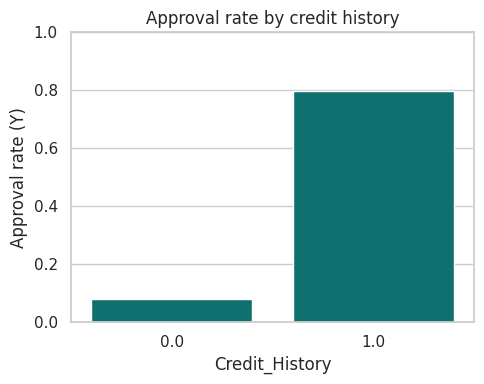

In [9]:
# 4) Credit history vs approval rate
credit = (
    df.dropna(subset=["Credit_History"])
    .groupby("Credit_History")["Loan_Status"]
    .apply(lambda s: (s == "Y").mean())
    .reset_index(name="approval_rate")
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=credit, x="Credit_History", y="approval_rate", ax=ax, color="teal")
ax.set_ylim(0, 1)
ax.set_ylabel("Approval rate (Y)")
ax.set_title("Approval rate by credit history")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_credit_history_approval.png", dpi=120)
plt.show()

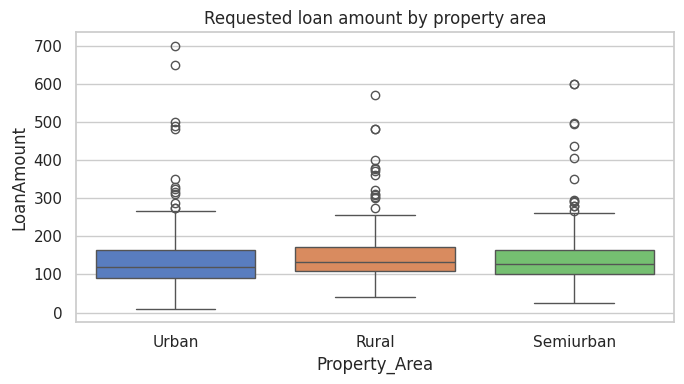

In [10]:
# 5) Loan amount by property area
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="Property_Area", y="LoanAmount", hue="Property_Area", legend=False, ax=ax)
ax.set_title("Requested loan amount by property area")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_loan_amount_by_area.png", dpi=120)
plt.show()

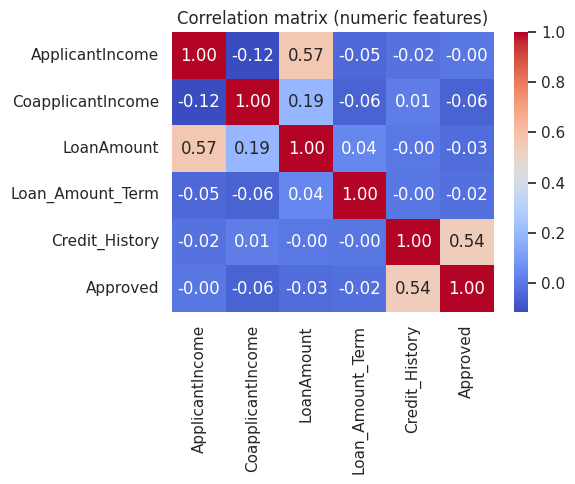

In [11]:
# 6) Correlation among numeric features (after simple imputation for EDA only)
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]
corr_df = df[num_cols].copy()
for c in num_cols:
    corr_df[c] = corr_df[c].fillna(corr_df[c].median())
corr_df["Approved"] = (df["Loan_Status"] == "Y").astype(int)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_correlation_heatmap.png", dpi=120)
plt.show()

**EDA takeaways**
- Target is imbalanced (~69% approved).
- `Credit_History` and income/loan features are central; several columns have missing data.
- Urban/semi-urban areas show different loan amount patterns.

## 3. Preprocessing

In [12]:
TARGET = "Loan_Status"
ID_COL = "Loan_ID"

raw = df.drop(columns=[ID_COL]).copy()
raw[TARGET] = (raw[TARGET] == "Y").astype(int)  # 1 = approved

cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]

# Impute before split (median/mode on full train later via pipeline — here for clarity we use simple rules)
processed = raw.copy()
for col in num_cols:
    processed[col] = processed[col].fillna(processed[col].median())
for col in cat_cols:
    processed[col] = processed[col].fillna(processed[col].mode(dropna=True).iloc[0])

X = processed.drop(columns=[TARGET])
y = processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

print("Train size:", X_train.shape, "| Test size:", X_test.shape)
print("Train approval rate:", y_train.mean().round(3))

Train size: (460, 11) | Test size: (154, 11)
Train approval rate: 0.687


## 4. Class imbalance strategies

We compare three approaches on the **training set only** (test set stays untouched):
1. **Class weights** in the classifier
2. **SMOTE** oversampling of the minority class
3. **Random undersampling** of the majority class

In [13]:
def make_preprocessed_xy(X_part, y_part, strategy):
    pipe = Pipeline([("prep", preprocessor)])
    X_mat = pipe.fit_transform(X_part, y_part)
    if strategy == "smote":
        sampler = SMOTE(random_state=RANDOM_STATE)
        X_res, y_res = sampler.fit_resample(X_mat, y_part)
    elif strategy == "undersample":
        sampler = RandomUnderSampler(random_state=RANDOM_STATE)
        X_res, y_res = sampler.fit_resample(X_mat, y_part)
    else:
        X_res, y_res = X_mat, y_part
    return X_res, y_res, pipe


def build_models(class_weight=None):
    cw = class_weight if class_weight else None
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=2000, class_weight=cw, random_state=RANDOM_STATE
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=5, class_weight=cw, random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=8, class_weight=cw, random_state=RANDOM_STATE
        ),
    }


IMBALANCE_STRATEGIES = ["class_weight", "smote", "undersample"]

## 5. Model training & evaluation

In [14]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, strategy):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        "model": name,
        "imbalance_strategy": strategy,
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_prob),
    }


results = []
fitted = {}

for strategy in IMBALANCE_STRATEGIES:
    cw = "balanced" if strategy == "class_weight" else None
    X_tr, y_tr, prep_pipe = make_preprocessed_xy(X_train, y_train, strategy)
    X_te = prep_pipe.transform(X_test)

    for name, model in build_models(class_weight=cw).items():
        row = evaluate_model(name, model, X_tr, y_tr, X_te, y_test, strategy)
        results.append(row)
        fitted[(strategy, name)] = (model, prep_pipe)

metrics_df = pd.DataFrame(results).sort_values("f1", ascending=False)
metrics_df

,model,imbalance_strategy,precision,recall,f1,roc_auc
4,Decision Tree,smote,0.804688,0.971698,0.880342,0.751278
2,Random Forest,class_weight,0.830508,0.924528,0.875000,0.814465
6,Logistic Regression,undersample,0.869159,0.877358,0.873239,0.845715
0,Logistic Regression,class_weight,0.875000,0.858491,0.866667,0.857311
5,Random Forest,smote,0.833333,0.896226,0.863636,0.806997
3,Logistic Regression,smote,0.872549,0.839623,0.855769,0.861242
8,Random Forest,undersample,0.834951,0.811321,0.822967,0.782429
7,Decision Tree,undersample,0.805825,0.783019,0.794258,0.711380
1,Decision Tree,class_weight,0.837209,0.679245,0.750000,0.761792


In [15]:
# Pivot for readability
pivot = metrics_df.pivot_table(
    index="model",
    columns="imbalance_strategy",
    values=["precision", "recall", "f1", "roc_auc"],
)
pivot.round(3)

f1                       precision         \
imbalance_strategy  class_weight  smote undersample class_weight  smote   
model                                                                     
Decision Tree              0.750  0.880       0.794        0.837  0.805   
Logistic Regression        0.867  0.856       0.873        0.875  0.873   
Random Forest              0.875  0.864       0.823        0.831  0.833   

                                      recall                         roc_auc  \
imbalance_strategy  undersample class_weight  smote undersample class_weight   
model                                                                          
Decision Tree             0.806        0.679  0.972       0.783        0.762   
Logistic Regression       0.869        0.858  0.840       0.877        0.857   
Random Forest             0.835        0.925  0.896       0.811        0.814   

                                        
imbalance_strategy   smote undersample  
model                                   
Decision Tree        0.751       0.711  
Logistic Regression  0.861       0.846  
Random Forest        0.807       0.782

In [16]:
# Cross-validation on best strategy (class weights) — logistic regression
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
cv_scores = cross_validate(
    pipe_lr, X, y,
    cv=cv,
    scoring=["precision", "recall", "f1", "roc_auc"],
    return_train_score=False,
)
pd.DataFrame({k.replace("test_", ""): [v.mean(), v.std()] for k, v in cv_scores.items() if k.startswith("test_")},
             index=["mean", "std"]).T.round(3)

,mean,std
precision,0.799,0.023
recall,0.837,0.047
f1,0.817,0.025
roc_auc,0.752,0.027


## 6. Model comparison highlights

In [17]:
best_f1 = metrics_df.iloc[0]
best_auc = metrics_df.loc[metrics_df["roc_auc"].idxmax()]
print("Highest test F1:", best_f1["model"], "+", best_f1["imbalance_strategy"],
      f"(F1={best_f1['f1']:.3f}, ROC-AUC={best_f1['roc_auc']:.3f})")
print("Highest test ROC-AUC:", best_auc["model"], "+", best_auc["imbalance_strategy"],
      f"(F1={best_auc['f1']:.3f}, ROC-AUC={best_auc['roc_auc']:.3f})")
metrics_df.pivot_table(index="model", columns="imbalance_strategy", values="roc_auc").round(3)

Highest test F1: Decision Tree + smote (F1=0.880, ROC-AUC=0.751)
Highest test ROC-AUC: Logistic Regression + smote (F1=0.856, ROC-AUC=0.861)


imbalance_strategy,class_weight,smote,undersample
model,,,
Decision Tree,0.762,0.751,0.711
Logistic Regression,0.857,0.861,0.846
Random Forest,0.814,0.807,0.782


**Deployment candidate:** Logistic Regression + `class_weight='balanced'` — best ROC-AUC and smooth probability scores for threshold tuning. Tree + SMOTE achieves similar F1 but coarse probabilities and lower ranking quality (ROC-AUC).

## 7. Deployment model evaluation (Logistic Regression + class weights)

              precision    recall  f1-score   support

Rejected (0)       0.70      0.73      0.71        48
Approved (1)       0.88      0.86      0.87       106

    accuracy                           0.82       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.82      0.82      0.82       154



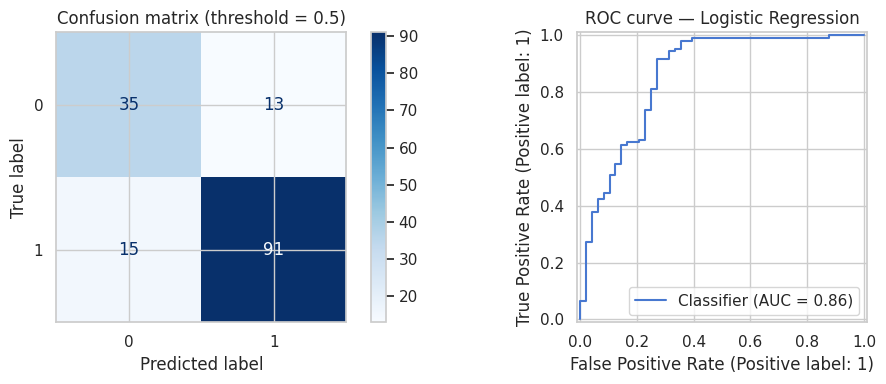

In [18]:
deploy_strategy = "class_weight"
deploy_name = "Logistic Regression"
deploy_model, deploy_prep = fitted[(deploy_strategy, deploy_name)]

X_te = deploy_prep.transform(X_test)
y_pred = deploy_model.predict(X_te)
y_prob = deploy_model.predict_proba(X_te)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion matrix (threshold = 0.5)")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("ROC curve — Logistic Regression")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_deploy_model_eval.png", dpi=120)
plt.show()

## 8. Threshold tuning for deployment

In [19]:
# Positive class = approved (1). Lower threshold → more approvals predicted.
candidate_thresholds = np.arange(0.40, 0.66, 0.01)
rows = []
for t in candidate_thresholds:
    pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    reject_recall = tn / (tn + fn) if (tn + fn) else 0  # catch bad loans
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall_approved": recall_score(y_test, pred, zero_division=0),
        "recall_rejected": reject_recall,
        "f1": f1_score(y_test, pred, zero_division=0),
        "approval_rate_pred": pred.mean(),
    })
thresh_df = pd.DataFrame(rows)

# Business rule: keep at least 50% recall on rejected class, then maximize F1
eligible = thresh_df[thresh_df["recall_rejected"] >= 0.50]
deploy_threshold = float(
    eligible.loc[eligible["f1"].idxmax(), "threshold"] if len(eligible) else thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
)
print(f"Suggested deployment threshold: {deploy_threshold:.2f}")
thresh_df.sort_values("f1", ascending=False).head(8)

Suggested deployment threshold: 0.40


,threshold,precision,recall_approved,recall_rejected,f1,approval_rate_pred
0,0.40,0.857143,0.962264,0.885714,0.906667,0.772727
1,0.41,0.857143,0.962264,0.885714,0.906667,0.772727
3,0.43,0.869565,0.943396,0.846154,0.904977,0.746753
4,0.44,0.869565,0.943396,0.846154,0.904977,0.746753
2,0.42,0.862069,0.943396,0.842105,0.900901,0.753247
5,0.45,0.868421,0.933962,0.825000,0.900000,0.740260
7,0.47,0.880734,0.905660,0.777778,0.893023,0.707792
6,0.46,0.866071,0.915094,0.785714,0.889908,0.727273


              precision    recall  f1-score   support

    Rejected       0.89      0.65      0.75        48
    Approved       0.86      0.96      0.91       106

    accuracy                           0.86       154
   macro avg       0.87      0.80      0.83       154
weighted avg       0.87      0.86      0.86       154



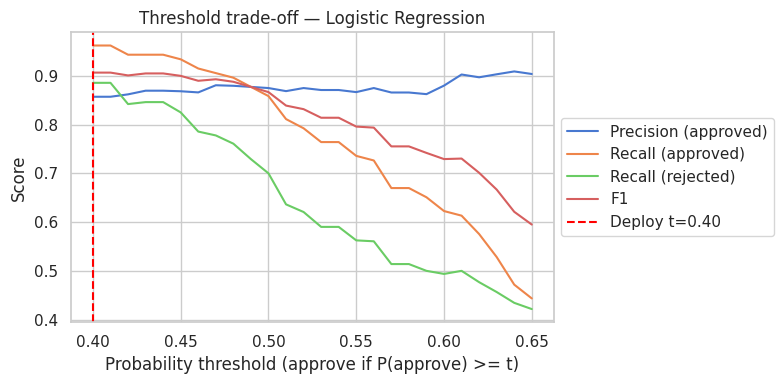

In [20]:
y_deploy = (y_prob >= deploy_threshold).astype(int)
print(classification_report(y_test, y_deploy, target_names=["Rejected", "Approved"]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision (approved)")
ax.plot(thresh_df["threshold"], thresh_df["recall_approved"], label="Recall (approved)")
ax.plot(thresh_df["threshold"], thresh_df["recall_rejected"], label="Recall (rejected)")
ax.plot(thresh_df["threshold"], thresh_df["f1"], label="F1")
ax.axvline(deploy_threshold, color="red", linestyle="--", label=f"Deploy t={deploy_threshold:.2f}")
ax.set_xlabel("Probability threshold (approve if P(approve) >= t)")
ax.set_ylabel("Score")
ax.set_title("Threshold trade-off — Logistic Regression")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(FIG_DIR / "08_threshold_analysis.png", dpi=120)
plt.show()

## 9. Business-oriented interpretation

In [21]:
# Feature importance for tree model (Random Forest + class weights)
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)),
])
rf_pipe.fit(X_train, y_train)
feat_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf_pipe.named_steps["clf"].feature_importances_, index=feat_names)
importances.sort_values(ascending=False).head(12)

num__Credit_History             0.237685
num__ApplicantIncome            0.164734
num__LoanAmount                 0.157650
num__CoapplicantIncome          0.109209
num__Loan_Amount_Term           0.047624
cat__Property_Area_Semiurban    0.035299
cat__Property_Area_Rural        0.023033
cat__Dependents_1               0.022044
cat__Dependents_0               0.020589
cat__Married_Yes                0.020375
cat__Education_Not Graduate     0.019845
cat__Education_Graduate         0.019773
dtype: float64

### How to read the model for business users

| Signal | Business meaning |
|--------|------------------|
| **Credit_History** | Strongest compliance signal: applicants meeting credit guidelines are far more likely to be approved. Manual overrides should be rare and documented. |
| **Income (applicant + co-applicant)** | Higher household income supports repayment capacity; borderline cases may need verified payslips. |
| **LoanAmount / Loan_Amount_Term** | High amount or long tenor increases risk; pricing and LTV caps can align with model risk. |
| **Property_Area** | Captures regional demand/risk; may proxy for collateral or local default rates. |
| **Demographics** (gender, married, dependents) | Use carefully; monitor for fairness. Prefer income and credit-based decisions where possible. |

**Operational framing**
- **False approval (FP):** Model says approve, applicant should be rejected → **credit loss risk**. Costly; tighten threshold or add rules on `Credit_History`.
- **False rejection (FN):** Model says reject, applicant would have repaid → **lost revenue / customer experience**. Slightly looser threshold or human review queue for borderline scores.

**Recommended deployment**
- Use **probability score** plus threshold from Section 7 (see `MODEL_REPORT.md`).
- Route scores in **[0.45, 0.60]** (example band around the optimum) to **manual underwriter review**.
- Track monthly precision/recall by segment (property area, income band) for drift.

In [22]:
print("Metrics summary saved. See MODEL_REPORT.md for deployment trade-offs.")
metrics_df.to_csv("outputs/model_metrics.csv", index=False)
thresh_df.to_csv("outputs/threshold_sweep.csv", index=False)
print("Wrote outputs/model_metrics.csv and outputs/threshold_sweep.csv")

Metrics summary saved. See MODEL_REPORT.md for deployment trade-offs.
Wrote outputs/model_metrics.csv and outputs/threshold_sweep.csv
